In [2]:
import pandas as pd
import json

# 1. Load the JSON logs into a Python list
data = []
with open('login_attempts.jsonl', 'r') as file:
    for line in file:
        data.append(json.loads(line))

# 2. Convert the list into a Pandas DataFrame
df = pd.DataFrame(data)

# 3. Parse the existing datetime string (removed the unit='s' parameter)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 4. Display the first 10 rows of our security logs
df.head(10)

,timestamp,ip_address,username,status,user_agent
0,2026-07-09 16:47:07,177.104.72.173,rzamora,SUCCESS,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_8 ...
1,2026-07-09 16:47:07,106.60.147.211,avilalisa,SUCCESS,Mozilla/5.0 (X11; Linux i686; rv:1.9.5.20) Gec...
2,2026-07-09 16:47:07,57.26.142.16,jamesdrake,SUCCESS,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_12_7...
3,2026-07-09 16:47:07,168.22.72.243,choinicholas,SUCCESS,Mozilla/5.0 (iPad; CPU iPad OS 17_4 like Mac O...
4,2026-07-09 16:47:07,88.236.224.161,aprilcooper,FAILED,Opera/9.42.(X11; Linux x86_64; bhb-IN) Presto/...
5,2026-07-09 16:47:07,147.144.143.159,robertrios,SUCCESS,Mozilla/5.0 (X11; Linux i686) AppleWebKit/535....
6,2026-07-09 16:47:07,78.34.241.40,woodcaitlin,FAILED,Mozilla/5.0 (Windows NT 5.2) AppleWebKit/536.1...
7,2026-07-09 16:47:07,126.69.68.72,robertperry,SUCCESS,Mozilla/5.0 (Windows; U; Windows NT 5.0) Apple...
8,2026-07-09 16:47:07,186.119.174.166,carmen55,FAILED,curl/7.68.0
9,2026-07-09 16:47:07,16.98.16.72,daniel63,FAILED,curl/7.68.0


Extracting Behavioral Features
We are going to group our logs by ip_address and calculate three critical security features:

total_logins: The raw velocity of requests.

unique_usernames: How many different accounts this IP tried to access.

failure_rate: The percentage of logins that resulted in a "FAILED" status.

In [3]:
ip_counts = df.groupby('ip_address').size().reset_index(name='total_logins')

unique_users = df.groupby('ip_address')['username'].nunique().reset_index(name='unique_usernames')

failed_logins = df[df['status']=='FAILED'].groupby('ip_address').size().reset_index(name='failed_logins')

features_df = ip_counts.merge(unique_users, on='ip_address', how='left')
features_df = features_df.merge(failed_logins, on='ip_address', how='left')

# Fill NaN values in 'failed_logins' with 0
features_df['failed_logins'] = features_df['failed_logins'].fillna(0)

#calculate failure rate
features_df['failure_rate'] = features_df['failed_logins'] / features_df['total_logins']

features_df.sort_values(by='failure_rate', ascending=True).head(15)


,ip_address,total_logins,unique_usernames,failed_logins,failure_rate
17,213.127.239.157,20,1,2,0.10
2,106.60.147.211,20,1,3,0.15
3,107.110.245.77,20,1,3,0.15
19,3.95.161.57,20,1,3,0.15
20,31.138.109.222,20,1,4,0.20
13,177.104.72.173,20,1,4,0.20
28,88.236.224.161,20,1,5,0.25
23,52.12.220.230,20,1,5,0.25
24,55.235.15.101,20,1,5,0.25
6,126.69.68.72,20,1,6,0.30


We are now going to make an unsupervised model, in this we will be using Isolation Forest

In [4]:
from sklearn.ensemble import IsolationForest

X = features_df[['total_logins', 'unique_usernames', 'failed_logins', 'failure_rate']]

#initialise the AI model
model = IsolationForest(n_estimators=100, contamination=0.15, random_state=42)

features_df['anomaly'] = model.fit_predict(X)

features_df['threat_score'] = features_df['anomaly'].map({1: 'normal', -1: 'Malicious Bot'})

caught_attackers = features_df[features_df['anomaly'] == -1]

caught_attackers.sort_values(by='total_logins', ascending=False).head(15)


,ip_address,total_logins,unique_usernames,failed_logins,failure_rate,anomaly,threat_score
9,16.98.16.72,50,50,50,1.00,-1,Malicious Bot
10,166.235.122.99,50,50,50,1.00,-1,Malicious Bot
12,173.2.127.71,50,50,50,1.00,-1,Malicious Bot
17,213.127.239.157,20,1,2,0.10,-1,Malicious Bot
21,39.112.141.12,20,1,7,0.35,-1,Malicious Bot


In [5]:
from sklearn.ensemble import IsolationForest
import plotly.express as px

# 1. Select the features
X = features_df[['total_logins', 'unique_usernames', 'failed_logins', 'failure_rate']]

# 2. THE FIX: Update contamination to 50% (0.50) because exactly half our IPs are bots
model = IsolationForest(n_estimators=100, contamination=0.50, random_state=42)

# 3. Train the model
features_df['anomaly_score'] = model.fit_predict(X)
features_df['threat_level'] = features_df['anomaly_score'].map({1: 'Normal Human', -1: 'Malicious Bot'})

# 4. Filter and show the caught attackers
caught_attackers = features_df[features_df['anomaly_score'] == -1]
print(f"[*] The AI flagged {len(caught_attackers)} IP addresses as malicious!")

# 5. GENERATE THE 3D THREAT LANDSCAPE
fig = px.scatter_3d(
    features_df,
    x='total_logins',
    y='unique_usernames',
    z='failure_rate',
    color='threat_level',
    color_discrete_map={'Normal Human': 'blue', 'Malicious Bot': 'red'},
    hover_data=['ip_address'],
    title='3D Threat Landscape: Humans vs. Bots',
    opacity=0.8
)

fig.show()

[*] The AI flagged 13 IP addresses as malicious!


Matplotlib is building the font cache; this may take a moment.


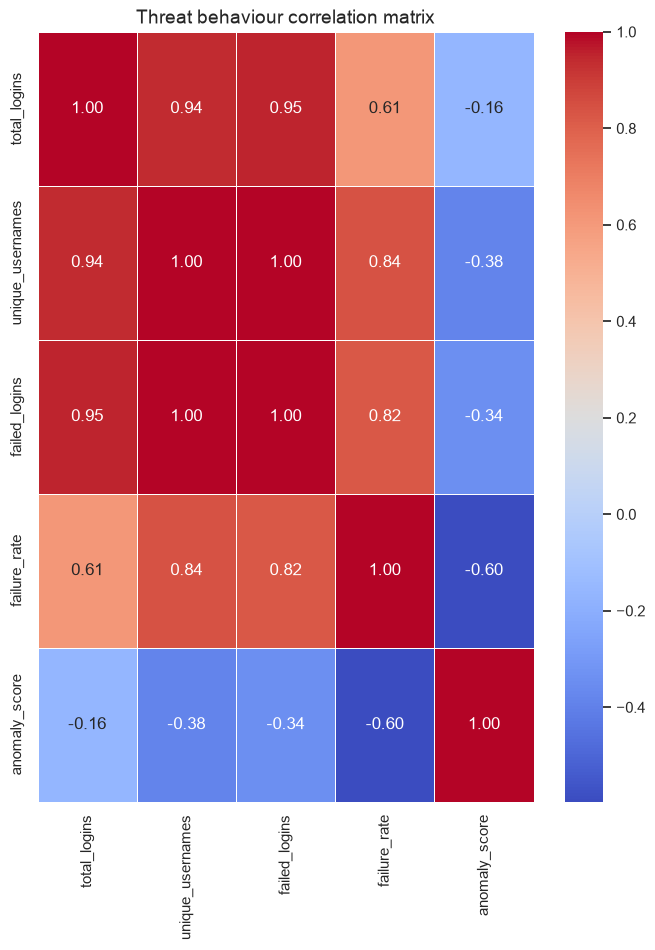

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid")

# Dashboard 1: The correlation heatmap: relationship between behaviours

plt.figure(figsize=(8, 10))
numeric_df = features_df[['total_logins', 'unique_usernames', 'failed_logins', 'failure_rate', 'anomaly_score']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Threat behaviour correlation matrix', fontsize=14)
plt.show()

/var/folders/gn/08r78gc16sxc8s0jp5p_w1840000gn/T/ipykernel_28999/469752959.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='threat_level', y='total_logins', data=features_df, ax=axes[0, 0], palette='muted')
/var/folders/gn/08r78gc16sxc8s0jp5p_w1840000gn/T/ipykernel_28999/469752959.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='threat_level', y='unique_usernames', data=features_df, ax=axes[0, 1], palette='muted')
/var/folders/gn/08r78gc16sxc8s0jp5p_w1840000gn/T/ipykernel_28999/469752959.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn

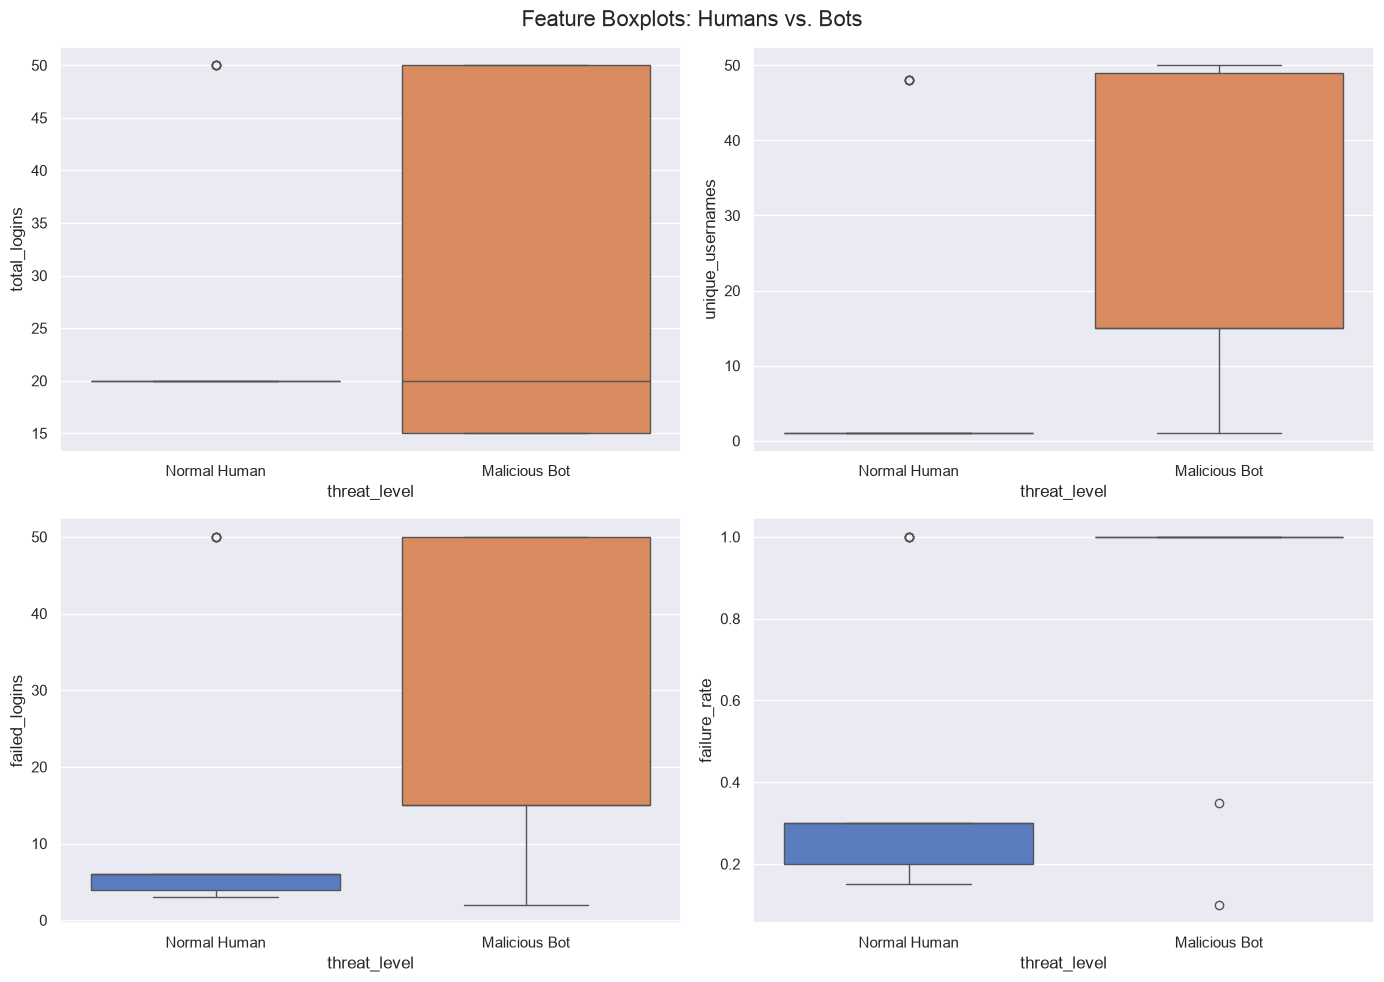

In [7]:
# Dashboard 2: feature boxplots: showing stastical spread for Humans vs. Bots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(x='threat_level', y='total_logins', data=features_df, ax=axes[0, 0], palette='muted')
sns.boxplot(x='threat_level', y='unique_usernames', data=features_df, ax=axes[0, 1], palette='muted')
sns.boxplot(x='threat_level', y='failed_logins', data=features_df, ax=axes[1, 0], palette='muted')
sns.boxplot(x='threat_level', y='failure_rate', data=features_df, ax=axes[1, 1], palette='muted')
plt.suptitle('Feature Boxplots: Humans vs. Bots', fontsize=16)
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

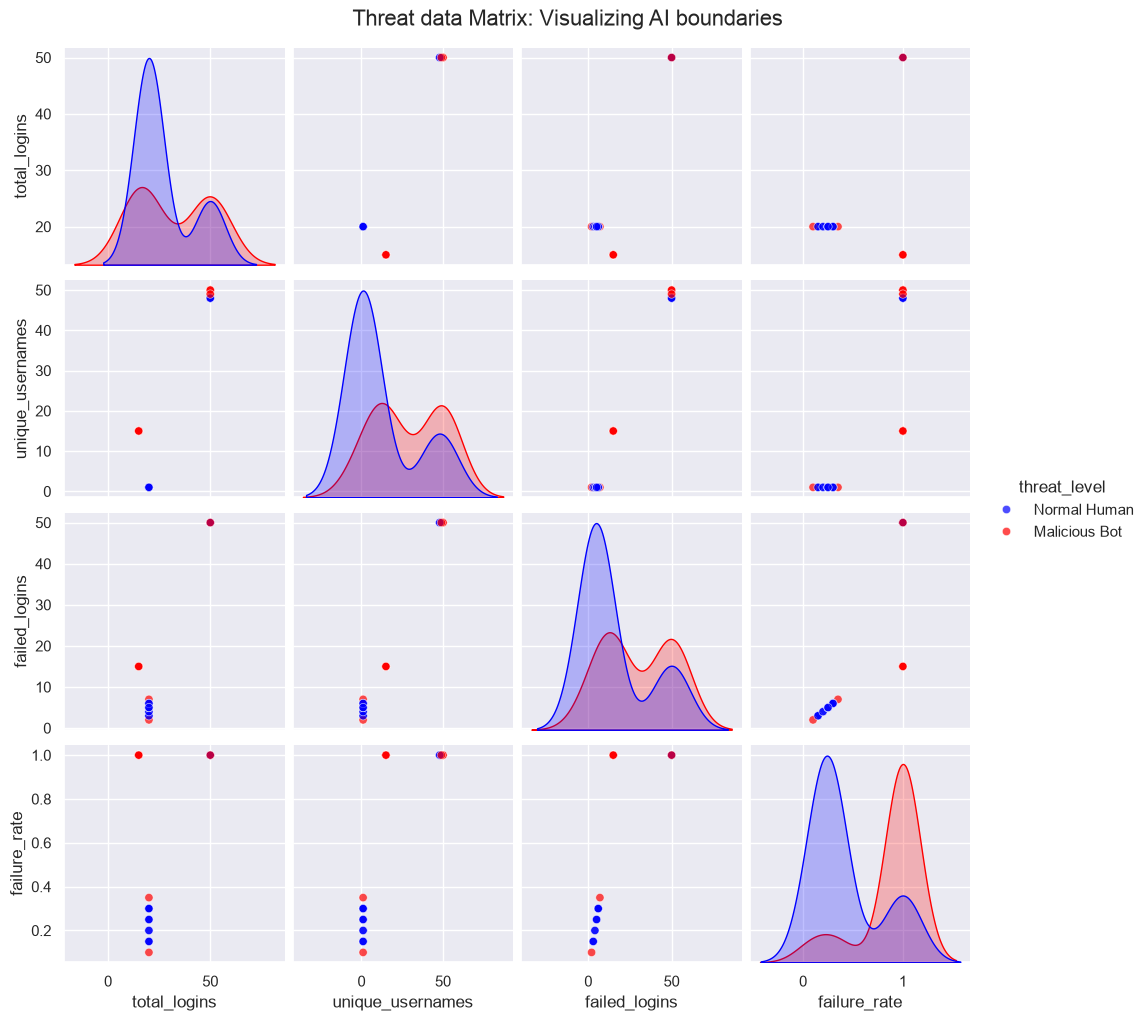

In [8]:
# Dashboard 3: The pairplot matrix: plots every single feature against each other
plt.figure(figsize=(12, 10))
sns.pairplot(
    features_df,
    hue='threat_level',
    vars=['total_logins', 'unique_usernames', 'failed_logins', 'failure_rate'],
    palette={'Normal Human': 'blue', 'Malicious Bot': 'red'},
    plot_kws={'alpha': 0.7}
)
plt.suptitle('Threat data Matrix: Visualizing AI boundaries', y=1.02, fontsize=16)
plt.show()